In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
data = pd.read_csv("dataset.csv", encoding="latin1")
print("Dataset Loaded Successfully")
data.head()

Dataset Loaded Successfully


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
data = data.dropna(subset=['Order Date', 'Sales'])
data['Sales'] = data['Sales'].fillna(data['Sales'].median())

In [4]:
# Step 4 — Clean Order Date Column & Convert to Datetime

# 1. Remove rows with missing or blank dates
data = data.dropna(subset=['Order Date'])

# 2. Convert to datetime safely (warning-free)
data['Order Date'] = pd.to_datetime(
    data['Order Date'],
    errors='coerce'   # invalid → NaT
)

# 3. Drop rows that still couldn't be converted
data = data.dropna(subset=['Order Date'])

In [5]:
data = data.sort_values("Order Date")

In [6]:
# Time Index (important for forecasting)
data['TimeIndex'] = np.arange(len(data))

# Extract date parts
data['Year'] = data['Order Date'].dt.year
data['Month'] = data['Order Date'].dt.month
data['Day'] = data['Order Date'].dt.day
data['DayOfWeek'] = data['Order Date'].dt.dayofweek
data['IsWeekend'] = data['DayOfWeek'].isin([5,6]).astype(int)

# Rolling averages (trend smoothing)
data['Rolling7'] = data['Sales'].rolling(7).mean().bfill()
data['Rolling30'] = data['Sales'].rolling(30).mean().bfill()

In [7]:
features = ['TimeIndex', 'Month', 'DayOfWeek', 'IsWeekend', 'Rolling7', 'Rolling30']
X = data[features]
y = data['Sales']

In [8]:
train_size = int(len(data) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [9]:
model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [10]:
predictions = model.predict(X_test)

In [11]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)

print("Mean Absolute Error:", round(mae, 2))
print("Root Mean Squared Error:", round(rmse, 2))

Mean Absolute Error: 262.13
Root Mean Squared Error: 472.63


In [12]:
results = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': predictions.round(2),
    'Error': (y_test.values - predictions).round(2)
})

results.head(10)

,Actual Sales,Predicted Sales,Error
0,15.400,122.21,-106.81
1,115.296,178.76,-63.47
2,24.640,109.96,-85.32
3,227.880,163.31,64.57
4,145.740,181.80,-36.06
5,70.120,171.29,-101.17
6,824.950,237.54,587.41
7,207.184,236.10,-28.91
8,31.128,150.49,-119.36
9,1473.100,487.52,985.58


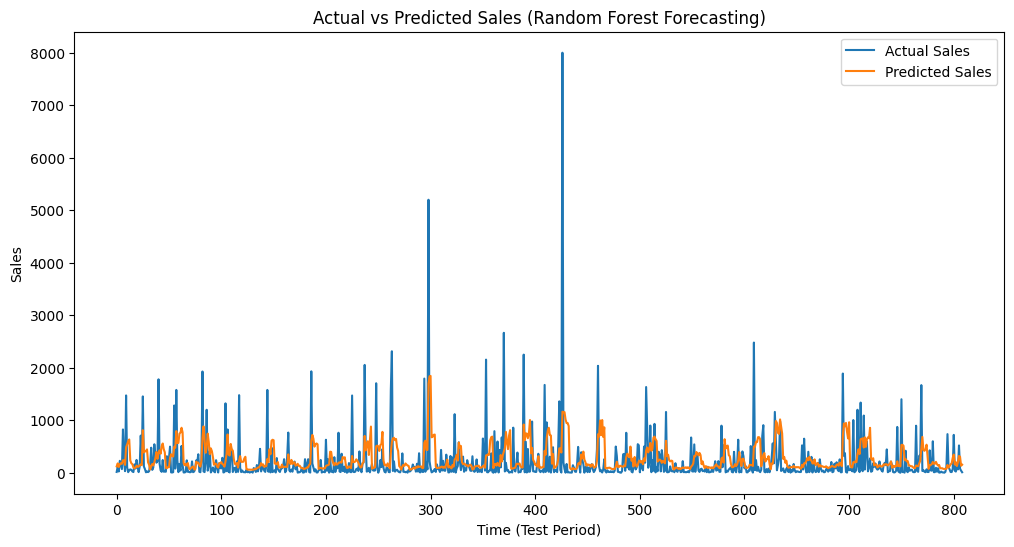

In [13]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual Sales")
plt.plot(predictions, label="Predicted Sales")

plt.title("Actual vs Predicted Sales (Random Forest Forecasting)")
plt.xlabel("Time (Test Period)")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [14]:
# -------------------------------------------------------
# Generate future TimeIndex
# -------------------------------------------------------
future_steps = 30
last_index = data['TimeIndex'].max()

future_df = pd.DataFrame({
    "TimeIndex": np.arange(last_index + 1, last_index + 1 + future_steps)
})

# -------------------------------------------------------
# Create future dates using last known date
# -------------------------------------------------------
last_date = data['Order Date'].max()
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=future_steps)
future_df["Order Date"] = future_dates

# -------------------------------------------------------
# Time-based features
# -------------------------------------------------------
future_df["Month"] = future_df["Order Date"].dt.month
future_df["DayOfWeek"] = future_df["Order Date"].dt.dayofweek
future_df["IsWeekend"] = future_df["DayOfWeek"].isin([5, 6]).astype(int)

# -------------------------------------------------------
# Recompute rolling windows using combined data
# -------------------------------------------------------
temp = pd.concat([data[['Order Date', 'Sales', 'Rolling7', 'Rolling30']], future_df], ignore_index=True)

# Recalculate rollings (avoid deprecated .fillna(method=...)
temp["Rolling7"] = temp["Sales"].rolling(7).mean().ffill()
temp["Rolling30"] = temp["Sales"].rolling(30).mean().ffill()

# Extract last 30 rows for future_df
future_df["Rolling7"] = temp["Rolling7"].iloc[-future_steps:].values
future_df["Rolling30"] = temp["Rolling30"].iloc[-future_steps:].values

# -------------------------------------------------------
# Select the EXACT feature columns used in training
# -------------------------------------------------------
future_features = future_df[["TimeIndex","Month","DayOfWeek","IsWeekend","Rolling7","Rolling30"]]

# -------------------------------------------------------
# Predict
# -------------------------------------------------------
future_predictions = model.predict(future_features)

future_df["PredictedSales"] = future_predictions

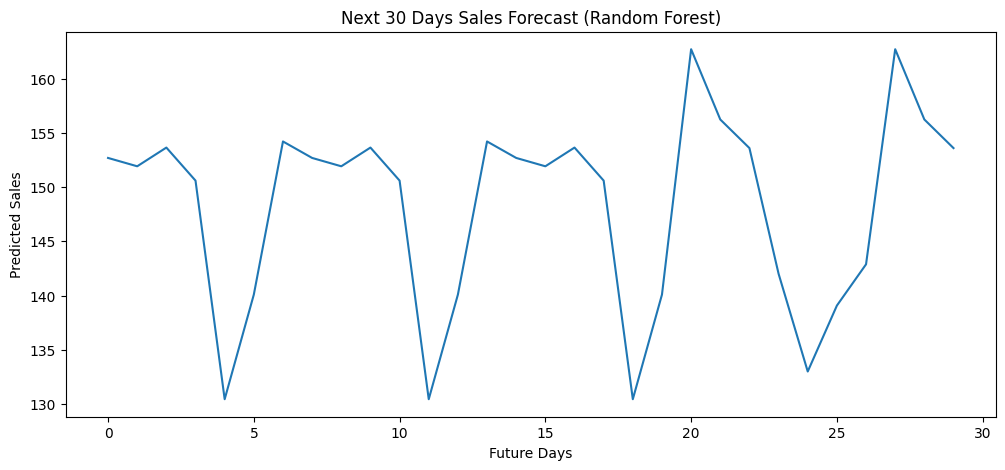

In [15]:
plt.figure(figsize=(12,5))
plt.plot(future_predictions)

plt.title("Next 30 Days Sales Forecast (Random Forest)")
plt.xlabel("Future Days")
plt.ylabel("Predicted Sales")
plt.show()